# Análisis Geoespacial IPM - Zona de Intervención: Avenida Ciudad de Cali (8 Tramos)

Este notebook prioriza la visualización cartográfica de las 5 variables más relevantes del Índice de Pobreza Multidimensional (IPM) en los 8 tramos del corredor Avenida Ciudad de Cali.

### Contexto y Cifras Generales (Corte Mayo 2026)

Para la interpretación de los resultados, se deben considerar dos lógicas opuestas:
1. **Índice de Condición Social (ICS):** Es un indicador directo; un valor del **100% representa el escenario óptimo** (bienestar y acceso pleno).
2. **Índice de Pobreza Multidimensional (IPM):** Es un indicador inverso; un valor del **100% representa el escenario crítico** (pobreza absoluta).

A nivel distrital, Cali presenta una marcada brecha territorial. La **severidad de la pobreza (IPM promedio en manzanas con incidencia > 0)** es del **15.28% en el área urbana**, mientras que en el **área rural se dispara al 38.33%**, impulsada principalmente por carencias en infraestructura básica en los corregimientos.

Este análisis se enfoca en los 8 tramos de la Avenida Ciudad de Cali para identificar las privaciones específicas que afectan a cada segmento de este corredor de intervención.

In [9]:
# 1. Instalación de dependencias (solo en Colab)
import sys
if 'google.colab' in sys.modules:
    !pip install geopandas matplotlib seaborn openpyxl -q

In [10]:
# 2. Importar librerías
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import matplotlib.colors as mcolors
from matplotlib.patheffects import withStroke
import matplotlib.patches as mpatches

sns.set_style('white')
print('Librerías listas')

Librerías listas


In [11]:
# 3. Definir rutas con detección de entorno
REPO_URL = 'https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social.git'
REPO_DIR = 'Pobreza_multidimensional_y_condicion_social'

if 'google.colab' in sys.modules:
    if not os.path.exists(REPO_DIR):
        !git clone {REPO_URL}
    else:
        !cd {REPO_DIR} && git pull
    BASE_DIR = REPO_DIR
else:
    if os.path.exists('indice_Pobreza'): BASE_DIR = '.'
    elif os.path.exists('../indice_Pobreza'): BASE_DIR = '..'
    elif os.path.exists('../../indice_Pobreza'): BASE_DIR = '../..'
    else: BASE_DIR = '.'

DATA_BASE = os.path.join(BASE_DIR, 'indice_Pobreza/data')

# Capas
PATH_IPM_VARS_FULL = os.path.join(DATA_BASE, 'geojson_ipm/Mzn_ipm_variables.geojson')
PATH_MANZANAS_FONDO = os.path.join(DATA_BASE, 'geojson_Manzanas_catastrales/geojson_Manzanas_catastrales.geojson')

# 8 tramos de Ciudad de Cali
TRAMOS = {
    'Tramo 1': os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_ciudad_de_cali_T1.geojson'),
    'Tramo 2': os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_ciudad_de_cali_T2.geojson'),
    'Tramo 3': os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_ciudad_de_cali_T3.geojson'),
    'Tramo 4': os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_ciudad_de_cali_T4.geojson'),
    'Tramo 5': os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_ciudad_de_cali_T5.geojson'),
    'Tramo 6': os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_ciudad_de_cali_T6.geojson'),
    'Tramo 7': os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_ciudad_de_cali_T7.geojson'),
    'Tramo 8': os.path.join(DATA_BASE, 'geojson_poligonos_territorio_ITT/poligono_ciudad_de_cali_T8.geojson'),
}

# Cargar datos base
gdf_full = gpd.read_file(PATH_IPM_VARS_FULL).to_crs('EPSG:4326')
gdf_fondo = gpd.read_file(PATH_MANZANAS_FONDO).to_crs('EPSG:4326')

# Cargar y unir los 8 tramos en un solo GeoDataFrame
tramos_gdfs = {}
for nombre, path in TRAMOS.items():
    tramos_gdfs[nombre] = gpd.read_file(path).to_crs('EPSG:4326')

# Unir todos los tramos para el área de estudio completa
gdf_area = pd.concat(tramos_gdfs.values(), ignore_index=True)
gdf_area = gpd.GeoDataFrame(gdf_area, crs='EPSG:4326')

# Filtrado espacial preciso (Centroide dentro de CUALQUIER tramo)
gdf_p = gdf_full.to_crs('EPSG:3115')
area_p = gdf_area.to_crs('EPSG:3115')
idx = gpd.sjoin(gdf_p.copy().assign(geometry=gdf_p.centroid), area_p[['geometry']], how='inner', predicate='within').index
# Eliminar duplicados (manzanas que caen en la intersección de tramos)
idx = idx[~idx.duplicated()]
gdf = gdf_full.loc[idx].copy()

print(f'Manzanas detectadas en Av. Ciudad de Cali (8 tramos): {len(gdf)}')
print(f'Tramos cargados: {len(TRAMOS)}')

remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 5 (delta 3), reused 5 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 3.83 MiB | 7.77 MiB/s, done.
From https://github.com/j0rg3c45/Pobreza_multidimensional_y_condicion_social
   443e180..cb60f0b  main       -> origin/main
Updating 443e180..cb60f0b
Fast-forward
 .../notebooks_py/07_mapeo_ipm_ciudad_de_cali.ipynb | 46 ++++++++++++----------
 1 file changed, 26 insertions(+), 20 deletions(-)
Manzanas detectadas en Av. Ciudad de Cali (8 tramos): 516
Tramos cargados: 8


Las 5 variables con mayor incidencia en Av. Ciudad de Cali son:
- Informalidad (INFOR_): 74.80%
- Bajo Logro Educativo (BAJO_): 34.60%
- Dependencia Económica (DEPEN_): 21.57%
- Sin Aseguramiento Salud (ASEGU_): 20.81%
- Rezago Escolar (REZAGO_): 15.96%


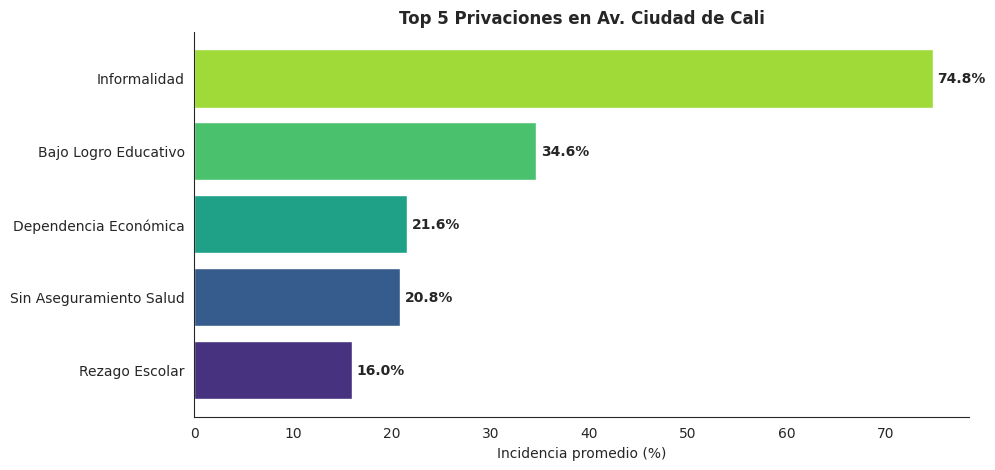

In [12]:
# 4. Escalas Maestras Notebook 01 (Comparabilidad Distrital)
RANGOS_IPM_8 = [
    (0.4, 20.0, "0.4% - 20.0%"),
    (20.1, 27.0, "20.1% - 27.0%"),
    (27.1, 33.1, "27.1% - 33.1%"),
    (33.2, 39.8, "33.2% - 39.8%"),
    (39.9, 48.6, "39.9% - 48.6%"),
    (48.7, 60.6, "48.7% - 60.6%"),
    (60.7, 80.0, "60.7% - 80.0%"),
    (80.1, 335.1, "80.1% - 335.1%")
]

# Usamos Viridis para variables IPM segun mandato de accesibilidad
cmap_master = plt.get_cmap("viridis", 8)
COLORES_IPM_8 = [mcolors.to_hex(cmap_master(i)) for i in range(8)]
CATEGORIAS_IPM_8 = ["Bajo", "Moderado-Bajo", "Moderado", "Moderado-Alto", "Alto", "Muy Alto", "Extremo", "Extremo Maximo"]

def _clasificar_ipm_master(gdf_zone, columna):
    datos = gdf_zone[columna].astype(float)
    cortes = [r[0] for r in RANGOS_IPM_8] + [RANGOS_IPM_8[-1][1]]
    etiquetas = [r[2] for r in RANGOS_IPM_8]

    res = gdf_zone.copy()
    res["_rango"] = pd.cut(datos, bins=cortes, labels=etiquetas, include_lowest=True, duplicates="drop")
    col_map = dict(zip(etiquetas, COLORES_IPM_8))
    res["_color"] = res["_rango"].astype(str).map(col_map).fillna("#BDBDBD")
    return res

# Variables IPM
variables_ipm = [
    'ANALF_', 'BAJO_', 'INFANCIA_', 'INASIS_', 'REZAGO_',
    'TRAB_INFAN', 'DEPEN_', 'INFOR_', 'SALUD_', 'ASEGU_',
    'HACI_', 'PARED_', 'EXCRE_', 'PISOS_', 'AGUA_'
]

diccionario_nombres = {
    'ANALF_': 'Analfabetismo', 'BAJO_': 'Bajo Logro Educativo', 'INFANCIA_': 'Barreras Infancia',
    'INASIS_': 'Inasistencia Escolar', 'REZAGO_': 'Rezago Escolar', 'TRAB_INFAN': 'Trabajo Infantil',
    'DEPEN_': 'Dependencia Económica', 'INFOR_': 'Informalidad', 'SALUD_': 'Barreras Salud',
    'ASEGU_': 'Sin Aseguramiento Salud', 'HACI_': 'Hacinamiento Crítico', 'PARED_': 'Paredes Inadecuadas',
    'EXCRE_': 'Excretas Inadecuadas', 'PISOS_': 'Pisos Inadecuados', 'AGUA_': 'Sin Agua Mejorada'
}

# Top 5 por incidencia promedio
top_5 = gdf[variables_ipm].mean().sort_values(ascending=False).head(5).index.tolist()
print('Las 5 variables con mayor incidencia en Av. Ciudad de Cali son:')
for v in top_5:
    print(f'- {diccionario_nombres[v]} ({v}): {gdf[v].mean():.2f}%')

# Visualización Ranking Top 5
top_means = gdf[top_5].mean().sort_values(ascending=True)
plt.figure(figsize=(10, 5))
plt.barh([diccionario_nombres[c] for c in top_means.index], top_means.values, color=cmap_master(np.linspace(0.2, 0.8, 5)))
for i, v in enumerate(top_means.values):
    plt.text(v + 0.5, i, f"{v:.1f}%", va='center', fontweight='bold')
plt.title("Top 5 Privaciones en Av. Ciudad de Cali", fontweight='bold')
plt.xlabel("Incidencia promedio (%)")
sns.despine()
plt.show()

In [13]:
# 5. Motor de Mapeo Maestro (Sincronización Total Colab 1)
# 5. Motor de Mapeo Maestro (Sincronización Total Colab 1)
# ============================================================================
# GUÍA DE AJUSTES RÁPIDOS:
# - mostrar_etiquetas: True/False → activa/desactiva valores IPM en manzanas
# - figsize=(18, 12) → tamaño de la figura (ancho, alto)
# - Zoom: ax.set_xlim / ax.set_ylim → ajustar rx*0.05 para más/menos margen
# - Leyenda: bbox_to_anchor=(1.01, 0.5) → mover horizontalmente (>1 = más derecha)
# - right=0.72 en subplots_adjust → espacio para la leyenda (menor = más espacio)
# - fontsize=7 en etiquetas → tamaño del texto dentro de manzanas
# - linewidth=1.5 del borde → grosor del polígono del área de estudio
# ============================================================================
def plot_ipm_variable_master(gdf_zone, gdf_back, gdf_poly, column, title, zona_nombre, mostrar_etiquetas=True):
    fig, ax = plt.subplots(1, 1, figsize=(18, 12))

    # --- 1. Capa Base (Cubre todo el lienzo) ---
    gdf_back.plot(ax=ax, color="#F8F8F8", edgecolor="#DCDCDC", linewidth=0.1, alpha=0.8, zorder=1)

    # --- 2. Clasificación Maestra ---
    gdf_cl = _clasificar_ipm_master(gdf_zone, column)

    # --- 3. Ploteo de Manzanas y Borde ---
    gdf_cl.plot(ax=ax, color=gdf_cl["_color"], edgecolor="white", linewidth=0.35, zorder=3, alpha=0.9)
    gdf_poly.boundary.plot(ax=ax, color="#D55E00", linewidth=1.5, linestyle="-", alpha=0.8, zorder=2)

    # --- 4. Etiquetas de Datos (desactivar con mostrar_etiquetas=False) ---
    if mostrar_etiquetas:
        for _, fila in gdf_cl.iterrows():
            if pd.isna(fila[column]): continue
            punto = fila.geometry.representative_point()
            valor = float(fila[column])
            txt_color = "white" if valor > 0 else "black"
            stk_color = "black" if valor > 0 else "white"
            ax.text(punto.x, punto.y, f"{valor:.1f}", fontsize=7, ha="center", va="center", fontweight="bold",
                    color=txt_color, path_effects=[withStroke(linewidth=1.5, foreground=stk_color, alpha=0.8)], zorder=5)

    # --- 5. Ajuste de Vista (Zoom) ---
    minx, miny, maxx, maxy = gdf_cl.total_bounds
    rx, ry = maxx - minx, maxy - miny
    ax.set_xlim(minx - rx*0.05, maxx + rx*0.05)
    ax.set_ylim(miny - ry*0.05, maxy + ry*0.05)

    # --- 6. Leyenda Maestra (fuera del mapa a la derecha) ---
    handles = [mpatches.Patch(facecolor=COLORES_IPM_8[i], edgecolor="white", label=f"{RANGOS_IPM_8[i][2]} | {CATEGORIAS_IPM_8[i]}") for i in range(8)]
    handles.append(mpatches.Patch(facecolor="none", edgecolor="#D55E00", linewidth=1.5, label="Area de estudio"))
    
    ax.legend(handles=handles, title=f"Privación: {title.upper()}\nRango % | Categoría",
              loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True, framealpha=0.9, fontsize=9, title_fontsize=11)
    
    ax.set_title(f"IPM por manzana: {title.upper()} - {zona_nombre}", fontsize=16, fontweight="bold", pad=20)
    ax.set_axis_off()
    plt.subplots_adjust(left=0.01, right=0.72, top=0.92, bottom=0.01)
    plt.show()

MAPAS CONSOLIDADOS - Av. Ciudad de Cali (8 tramos)


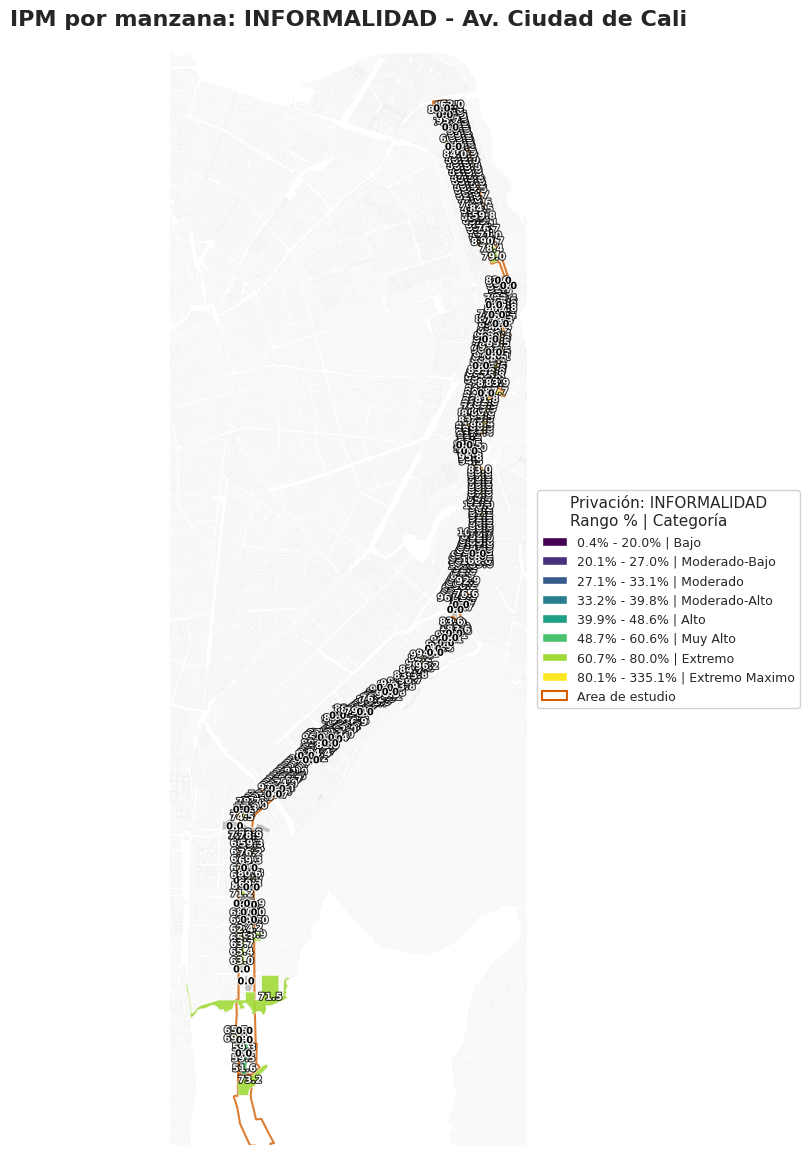

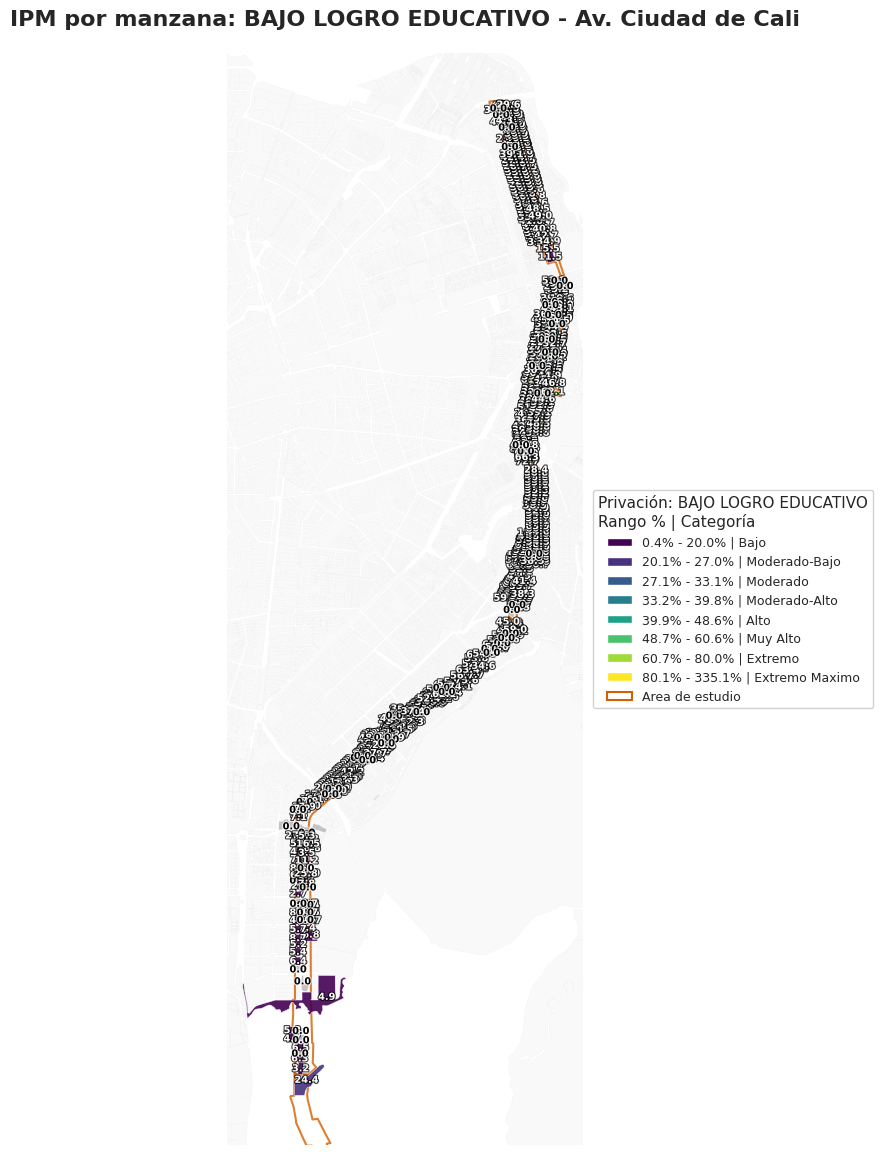

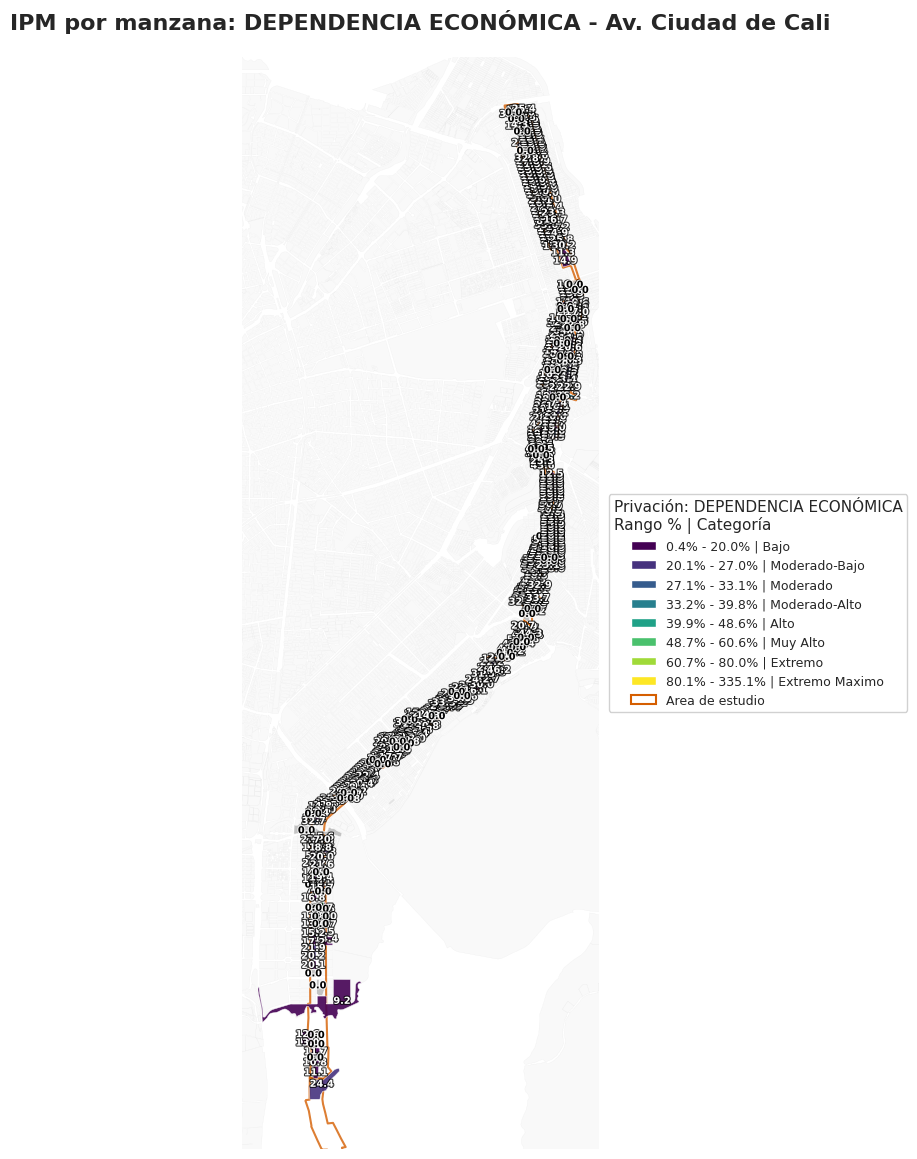

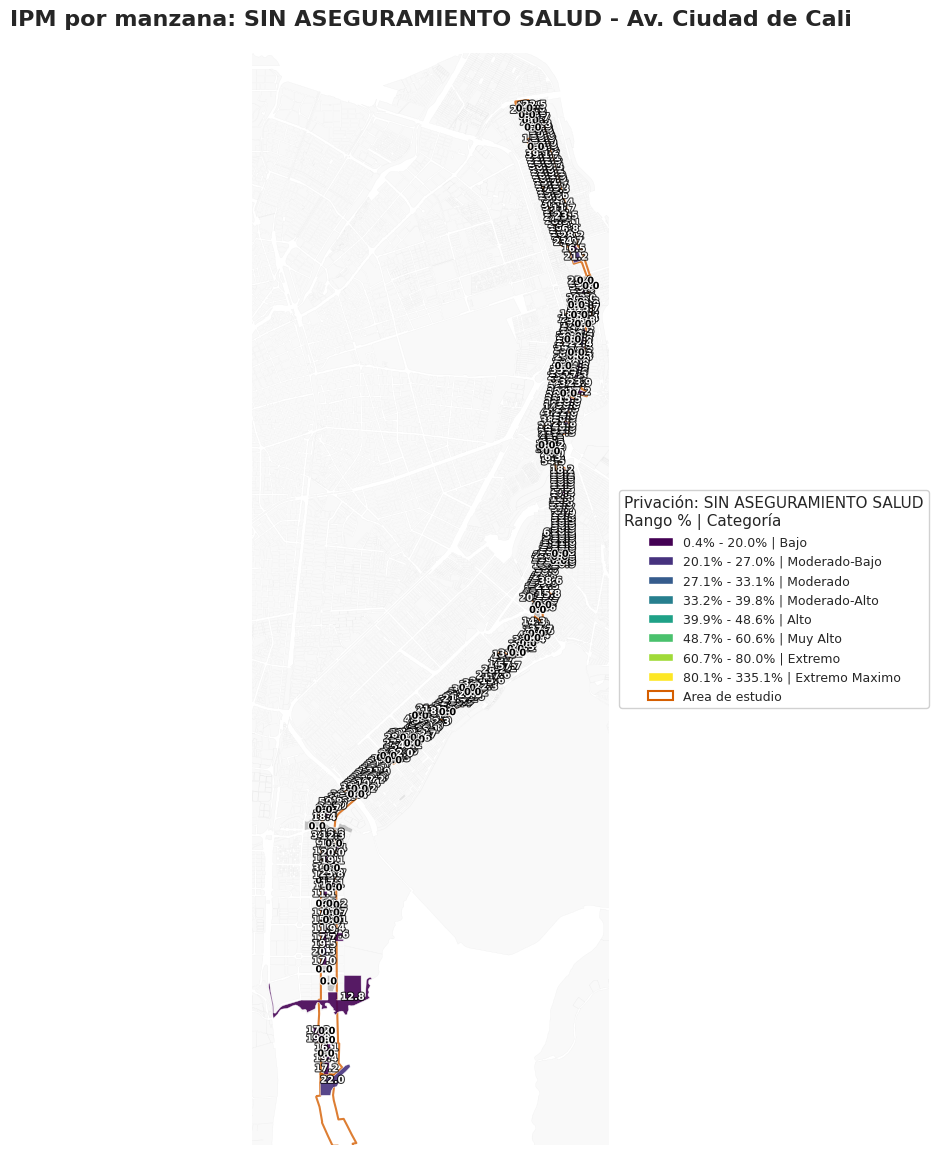

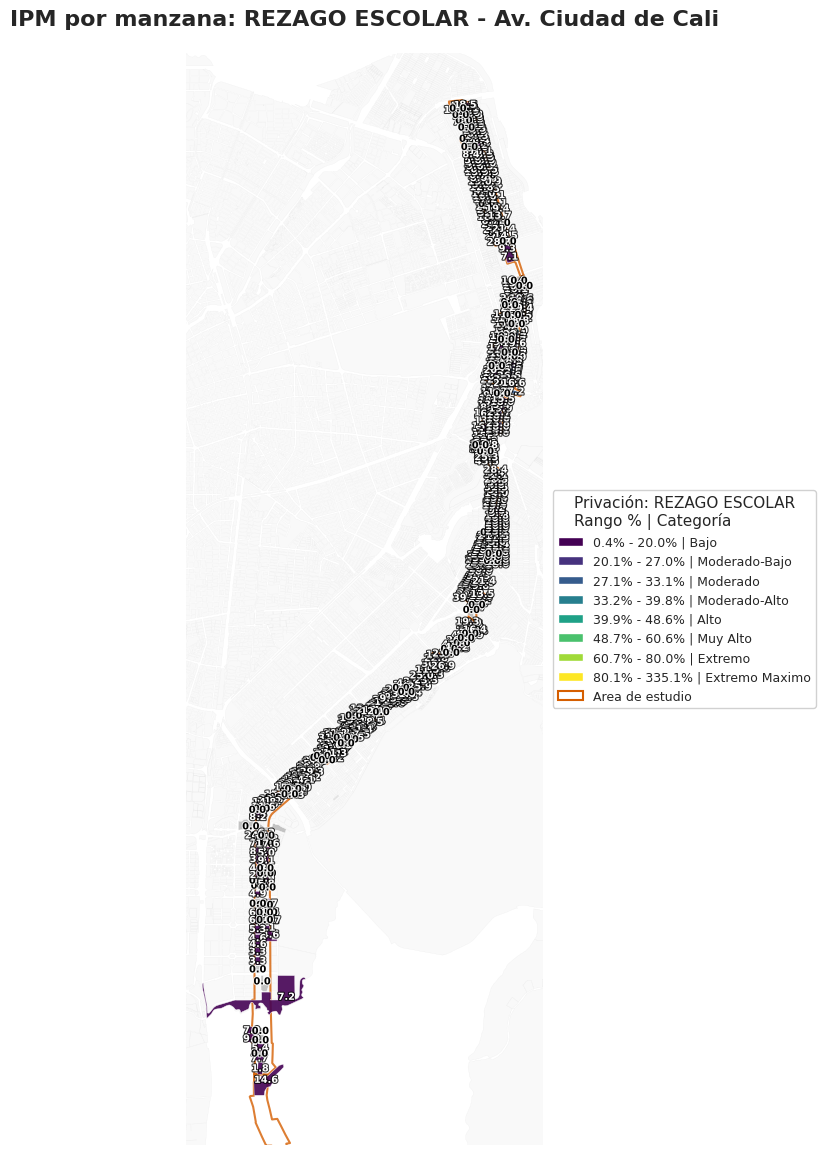

In [14]:
# 6. Generar mapas para TODOS los tramos combinados (SIN etiquetas por escala)
print('='*60)
print('MAPAS CONSOLIDADOS - Av. Ciudad de Cali (8 tramos)')
print('='*60)
for var in top_5:
    plot_ipm_variable_master(gdf, gdf_fondo, gdf_area, var, diccionario_nombres[var], 'Av. Ciudad de Cali', mostrar_etiquetas=False)


MAPAS POR TRAMO INDIVIDUAL

Variable más crítica: Informalidad

Tramo 1: 41 manzanas


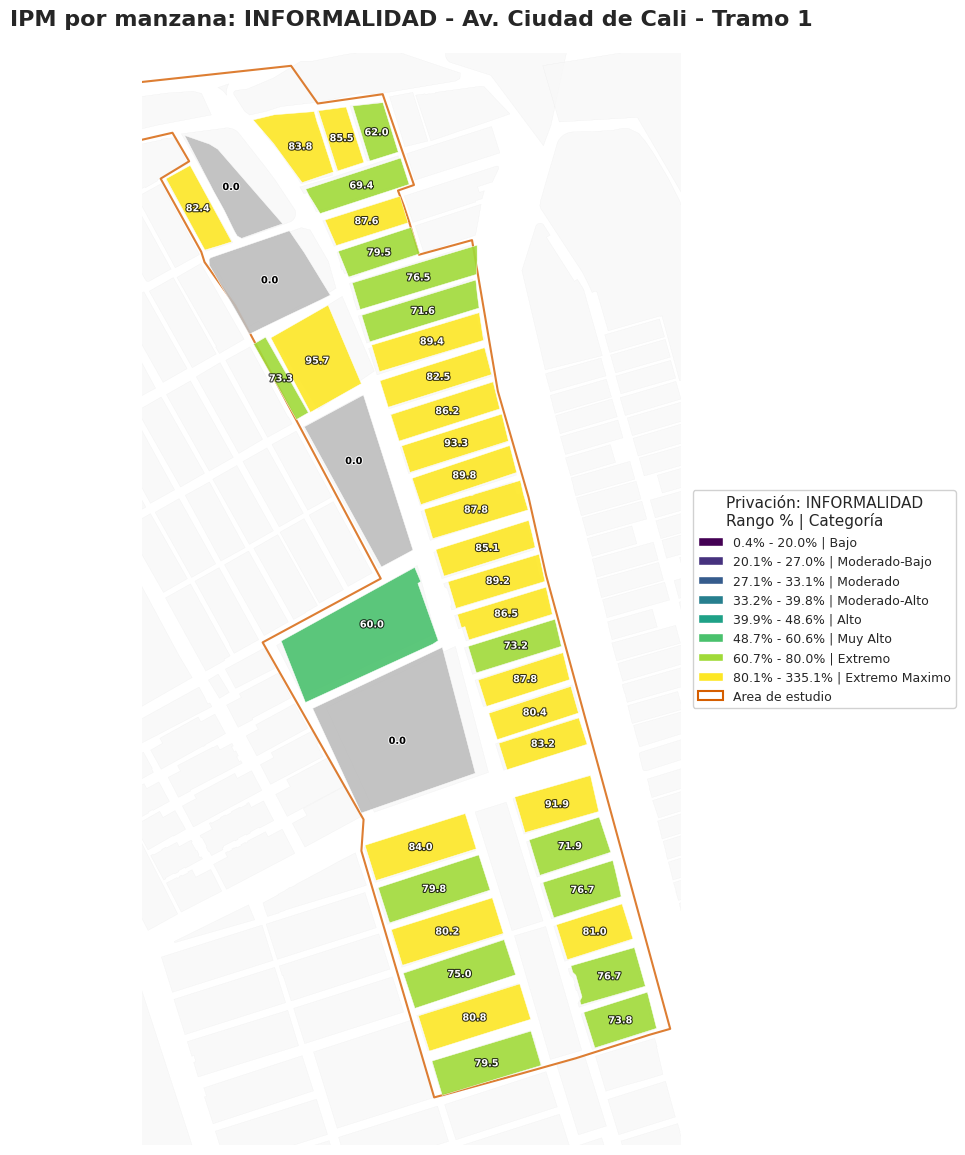

Tramo 2: 41 manzanas


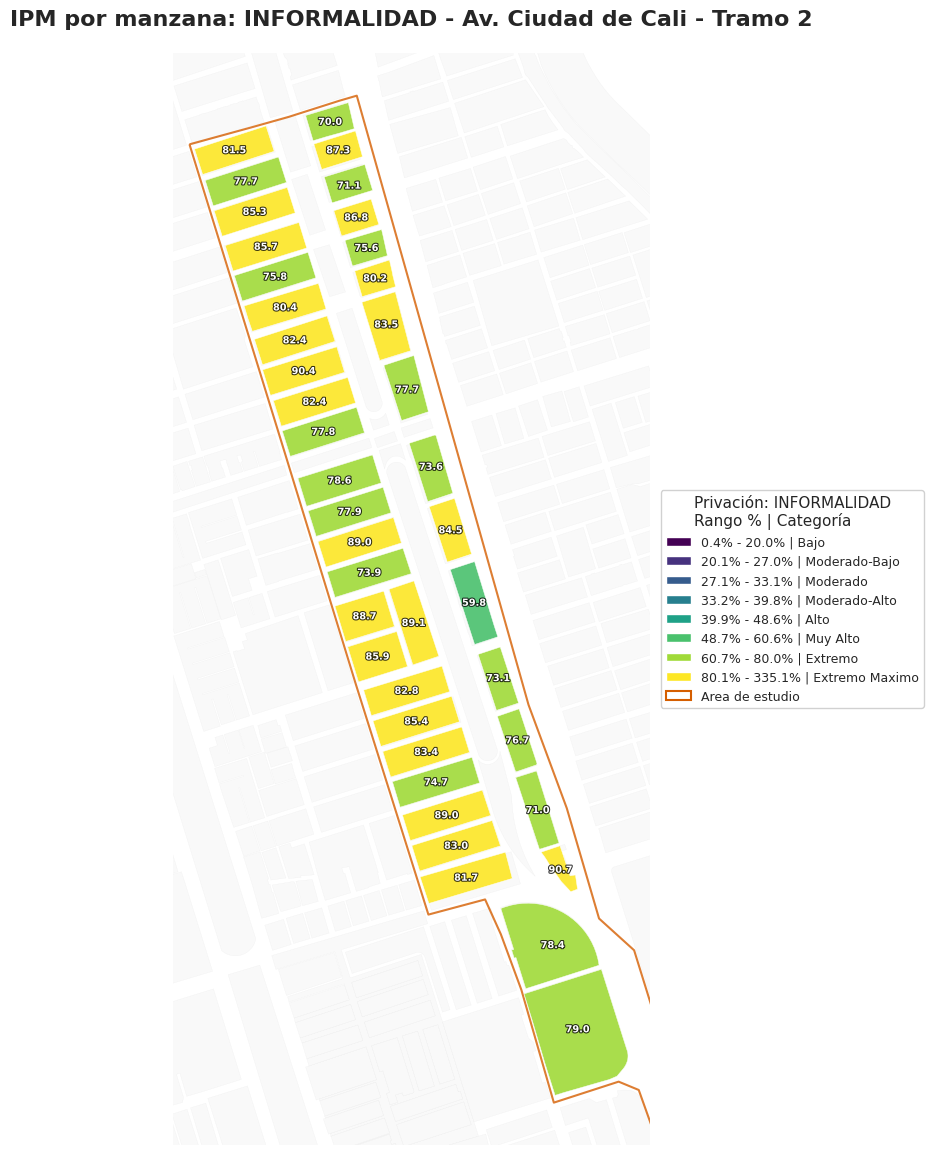

Tramo 3: 90 manzanas


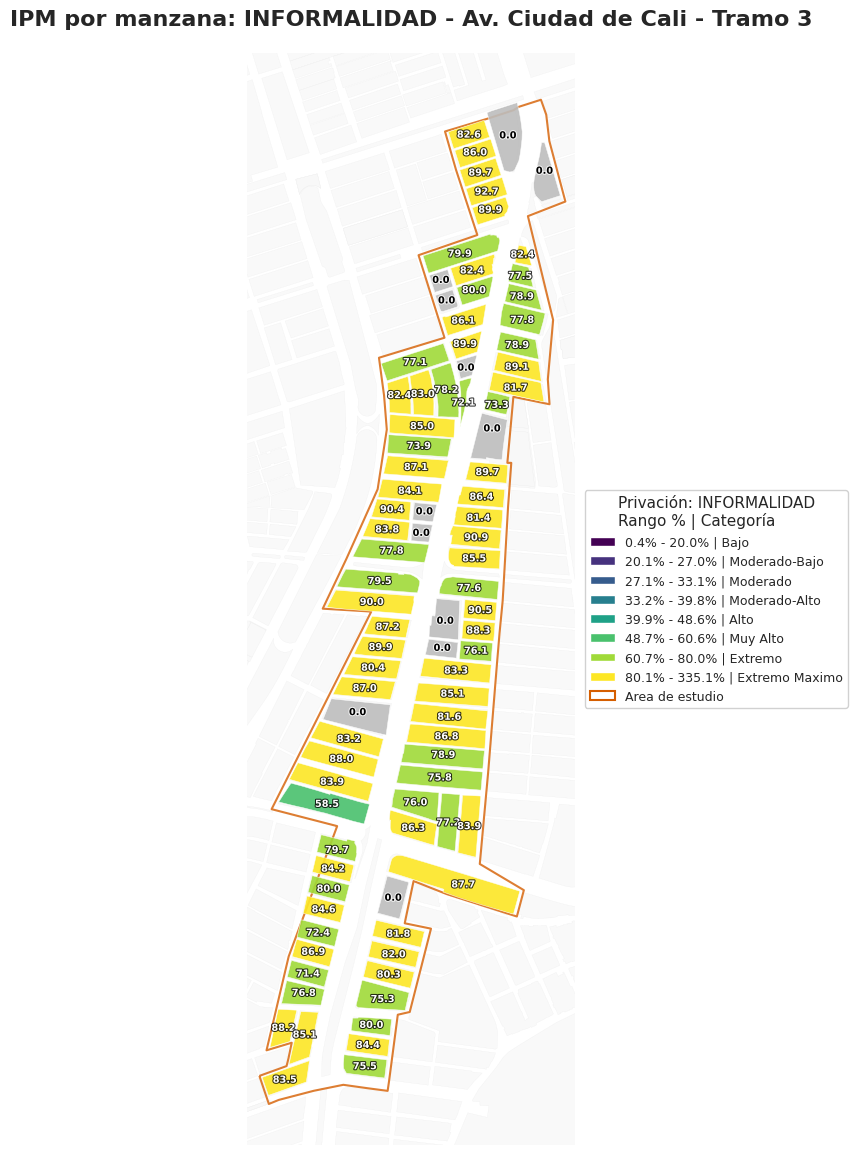

Tramo 4: 110 manzanas


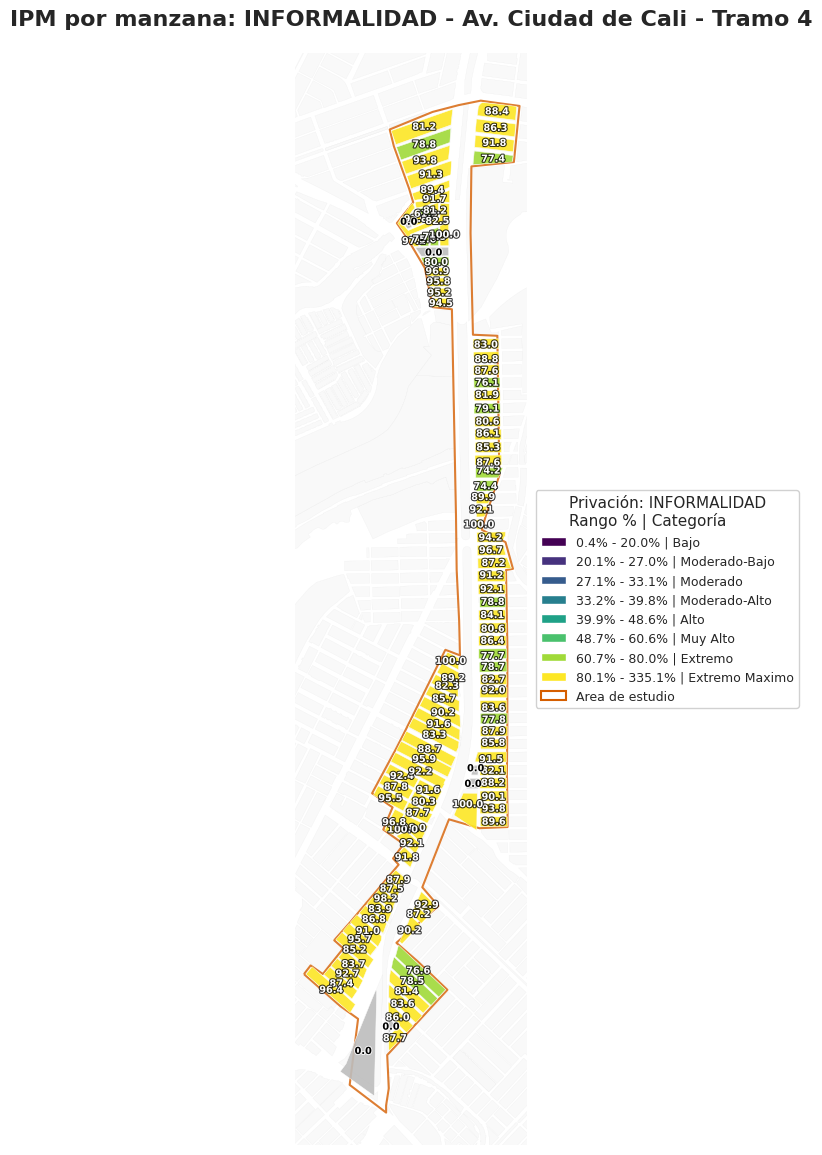

Tramo 5: 67 manzanas


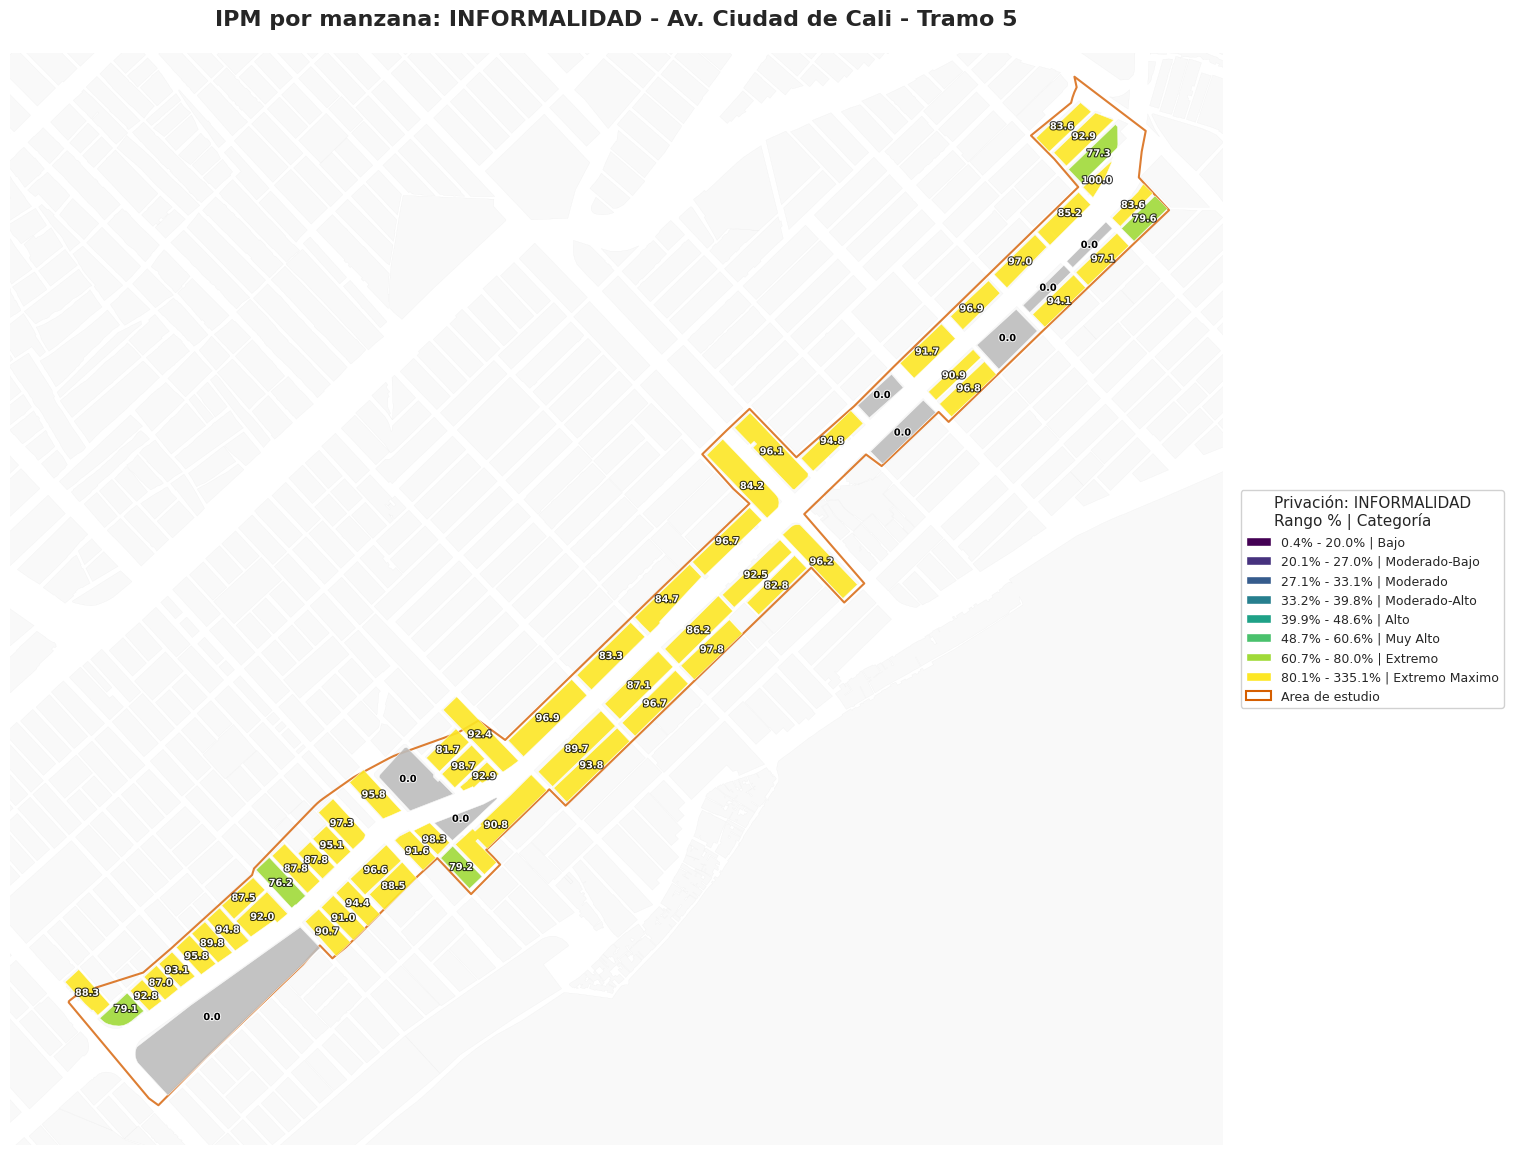

Tramo 6: 98 manzanas


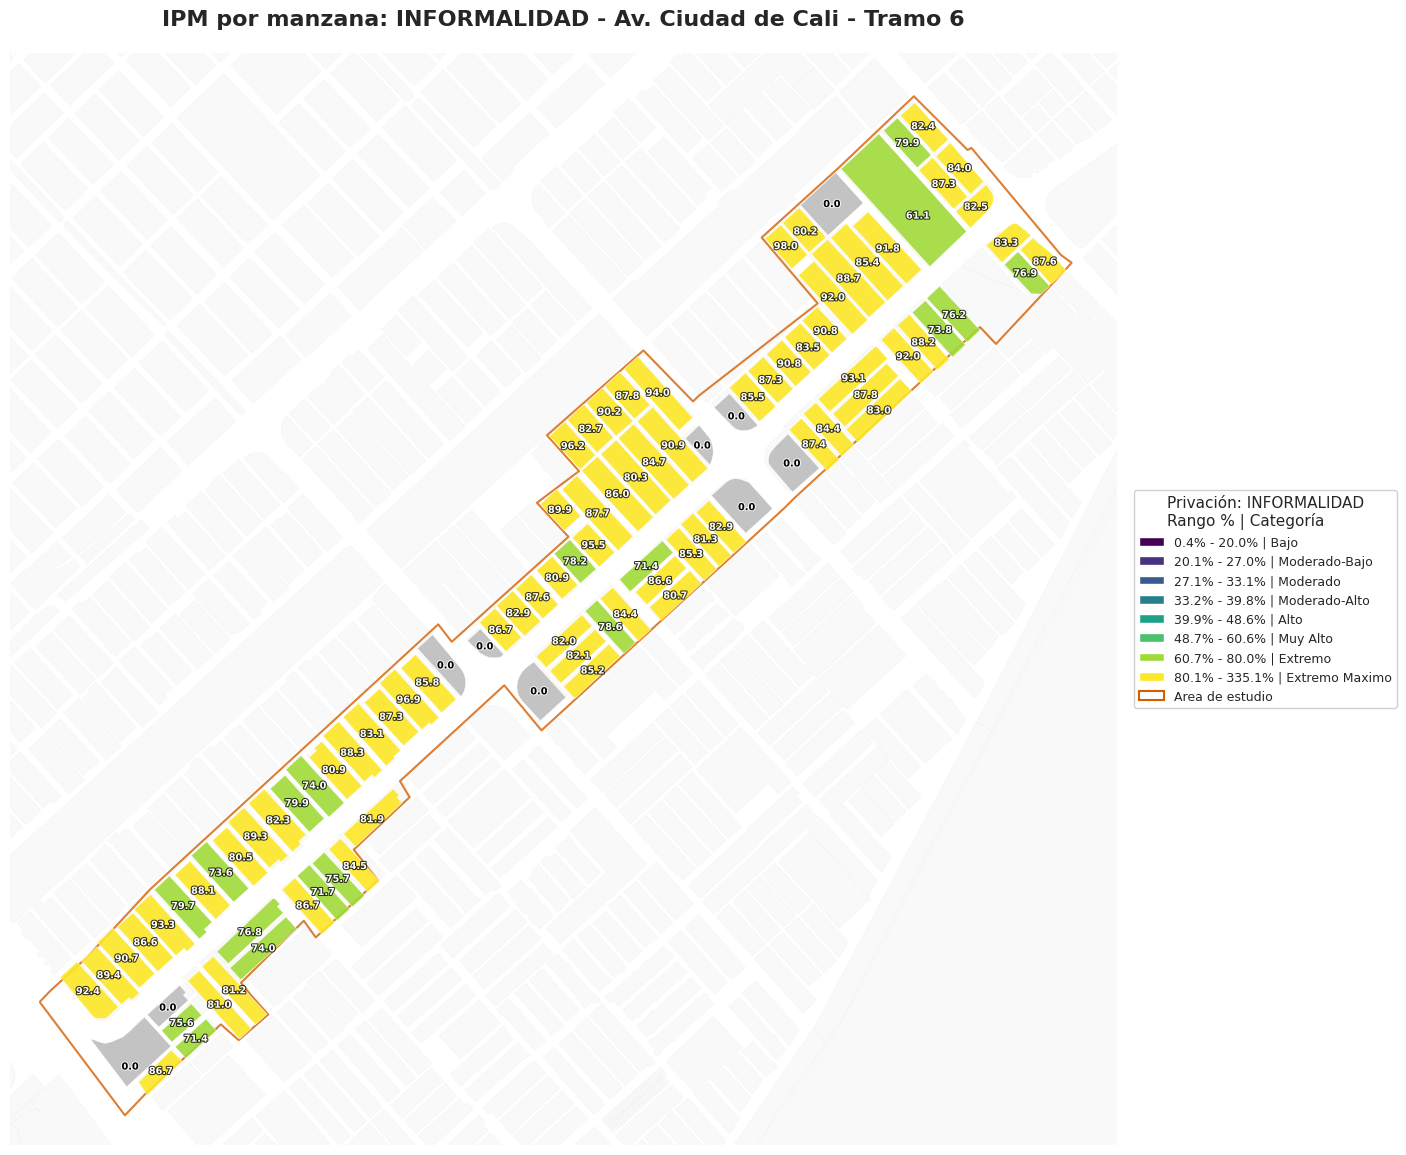

Tramo 7: 68 manzanas


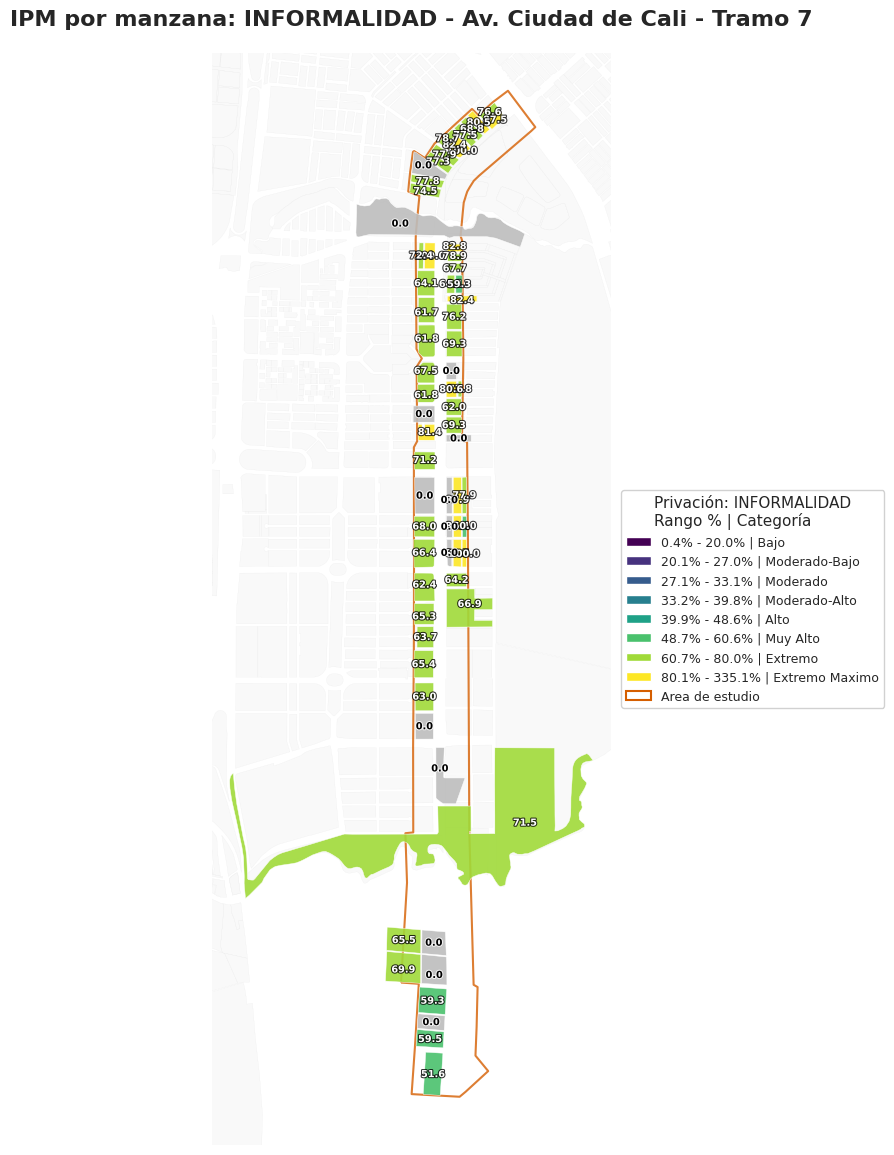

Tramo 8: 1 manzanas


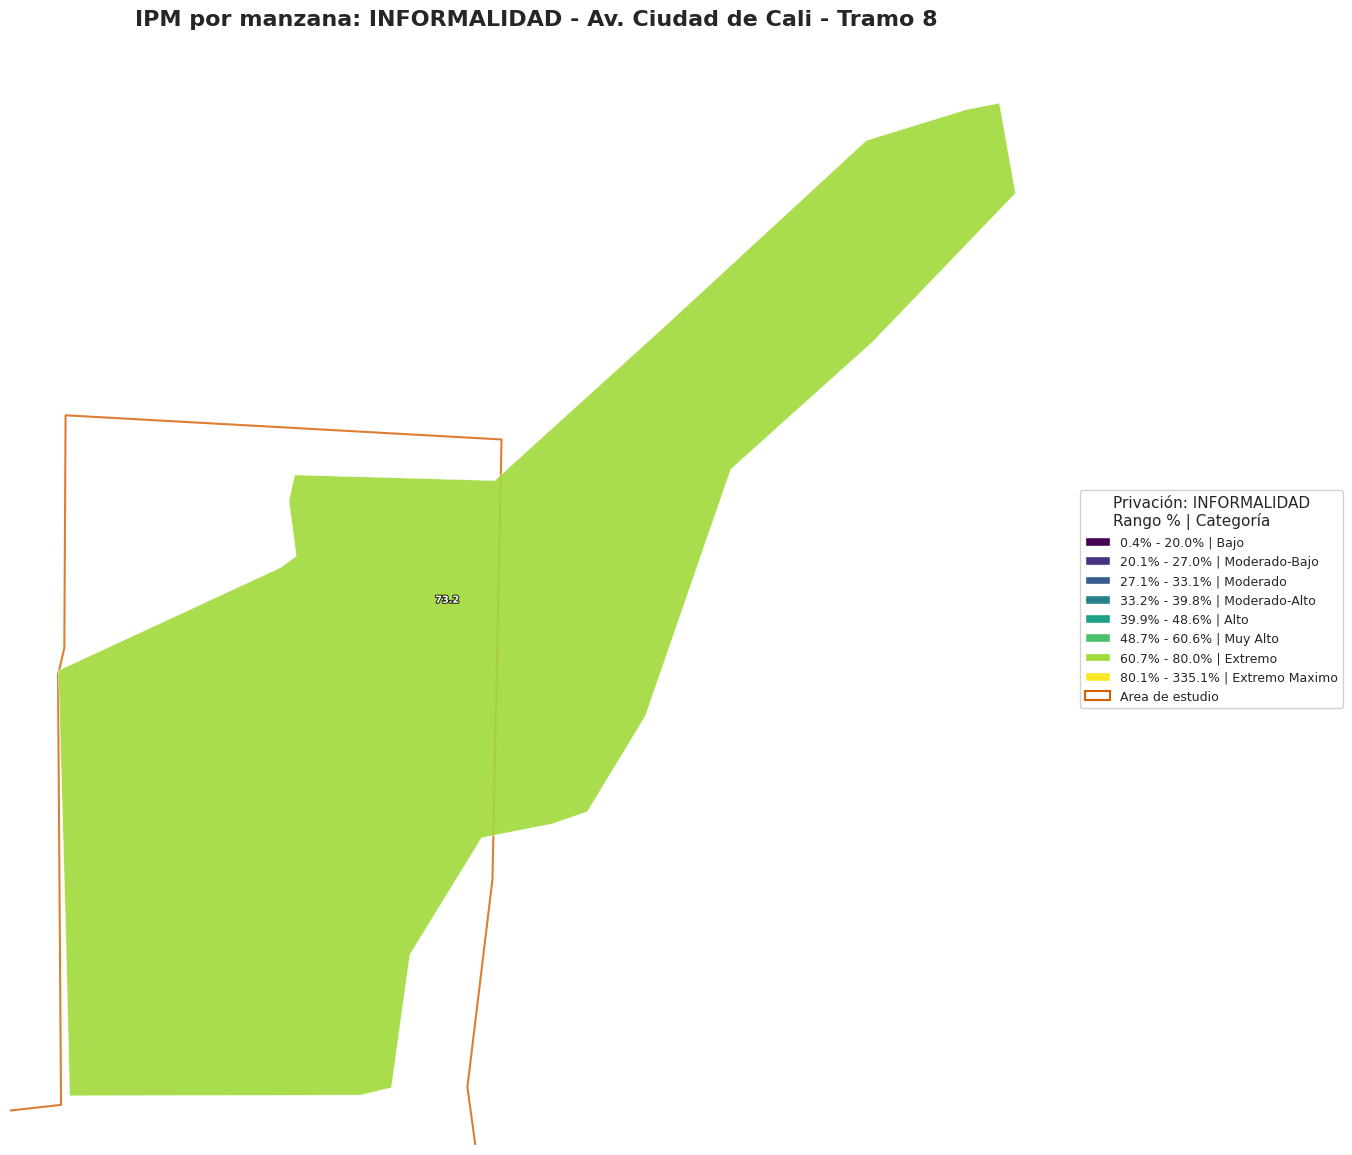

In [15]:
# 7. Generar mapas por TRAMO INDIVIDUAL
print('\n' + '='*60)
print('MAPAS POR TRAMO INDIVIDUAL')
print('='*60)

# Para cada tramo, filtrar manzanas y generar mapa de la variable más crítica
var_critica = top_5[0]  # La variable con mayor incidencia
print(f'\nVariable más crítica: {diccionario_nombres[var_critica]}')
print()

for nombre_tramo, path_tramo in TRAMOS.items():
    gdf_tramo_poly = gpd.read_file(path_tramo).to_crs('EPSG:4326')
    
    # Filtrado espacial para este tramo
    tramo_p = gdf_tramo_poly.to_crs('EPSG:3115')
    idx_tramo = gpd.sjoin(gdf_p.copy().assign(geometry=gdf_p.centroid), tramo_p[['geometry']], how='inner', predicate='within').index
    gdf_tramo = gdf_full.loc[idx_tramo].copy()
    
    if len(gdf_tramo) == 0:
        print(f'{nombre_tramo}: Sin manzanas IPM detectadas')
        continue
    
    print(f'{nombre_tramo}: {len(gdf_tramo)} manzanas')
    plot_ipm_variable_master(gdf_tramo, gdf_fondo, gdf_tramo_poly, var_critica, 
                             diccionario_nombres[var_critica], f'Av. Ciudad de Cali - {nombre_tramo}')

In [16]:
# 8. Descargar GeoJSON a tu PC (solo funciona en Google Colab)
if 'google.colab' in sys.modules:
    from google.colab import files
    output_path = os.path.join(BASE_DIR, 'indice_Pobreza/outputs/IPM_manzanas_Ciudad_de_Cali.geojson')
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    gdf.to_file(output_path, driver='GeoJSON')
    files.download(output_path)
    print(f'Descarga iniciada: IPM_manzanas_Ciudad_de_Cali.geojson ({len(gdf)} manzanas)')
else:
    print(f'Archivo fuente: {PATH_IPM_VARS_FULL}')
    print(f'Manzanas en zona (8 tramos): {len(gdf)}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Descarga iniciada: IPM_manzanas_Ciudad_de_Cali.geojson (516 manzanas)
